# Endogenous Investment and Demand-Constrained Stagnation

**Research question.** *Can endogenous investment financed through accumulated
private savings mitigate demand-constrained stagnation in a heterogeneous
Keynesian economy?*

This notebook compares two economies that differ **only** in the investment
propensity `theta`:

* **Baseline (`theta = 0`)** — capitalist savings pile up as an idle money hoard
  and never return to the circular flow of income.
* **Endogenous investment (`theta > 0`)** — capitalists convert a fraction of
  their accumulated savings into productive capital each period.

Every scenario is Monte-Carlo'd across many random seeds; lines show the mean
across seeds and shaded bands the 95% confidence interval on that mean.


In [1]:
import sys, os
sys.path.append(os.path.abspath(os.path.join('..', 'src')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from experiment import run_experiment, summarize, theta_sweep

sns.set_theme(style="ticks", context="paper", font_scale=1.2)

STEPS = 500
SEEDS = 30

BASELINE_THETA = 0.0
INVESTMENT_THETA = 0.15


C:\Users\recursivechaos\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Run the two economies

In [2]:
baseline_panel   = run_experiment(BASELINE_THETA,   steps=STEPS, seeds=SEEDS)
investment_panel = run_experiment(INVESTMENT_THETA, steps=STEPS, seeds=SEEDS)

baseline   = summarize(baseline_panel)
investment = summarize(investment_panel)

print("Baseline final output   :", round(baseline["Output_mean"].iloc[-1], 2))
print("Investment final output :", round(investment["Output_mean"].iloc[-1], 2))


C:\Users\recursivechaos\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mesa\mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


Baseline final output   : 52.94
Investment final output : 147.87


## 2. Macroeconomic dynamics

`Output` is plotted against `Potential_Output` (dashed) so the **output gap** —
the hallmark of demand-constrained stagnation — is visible directly.


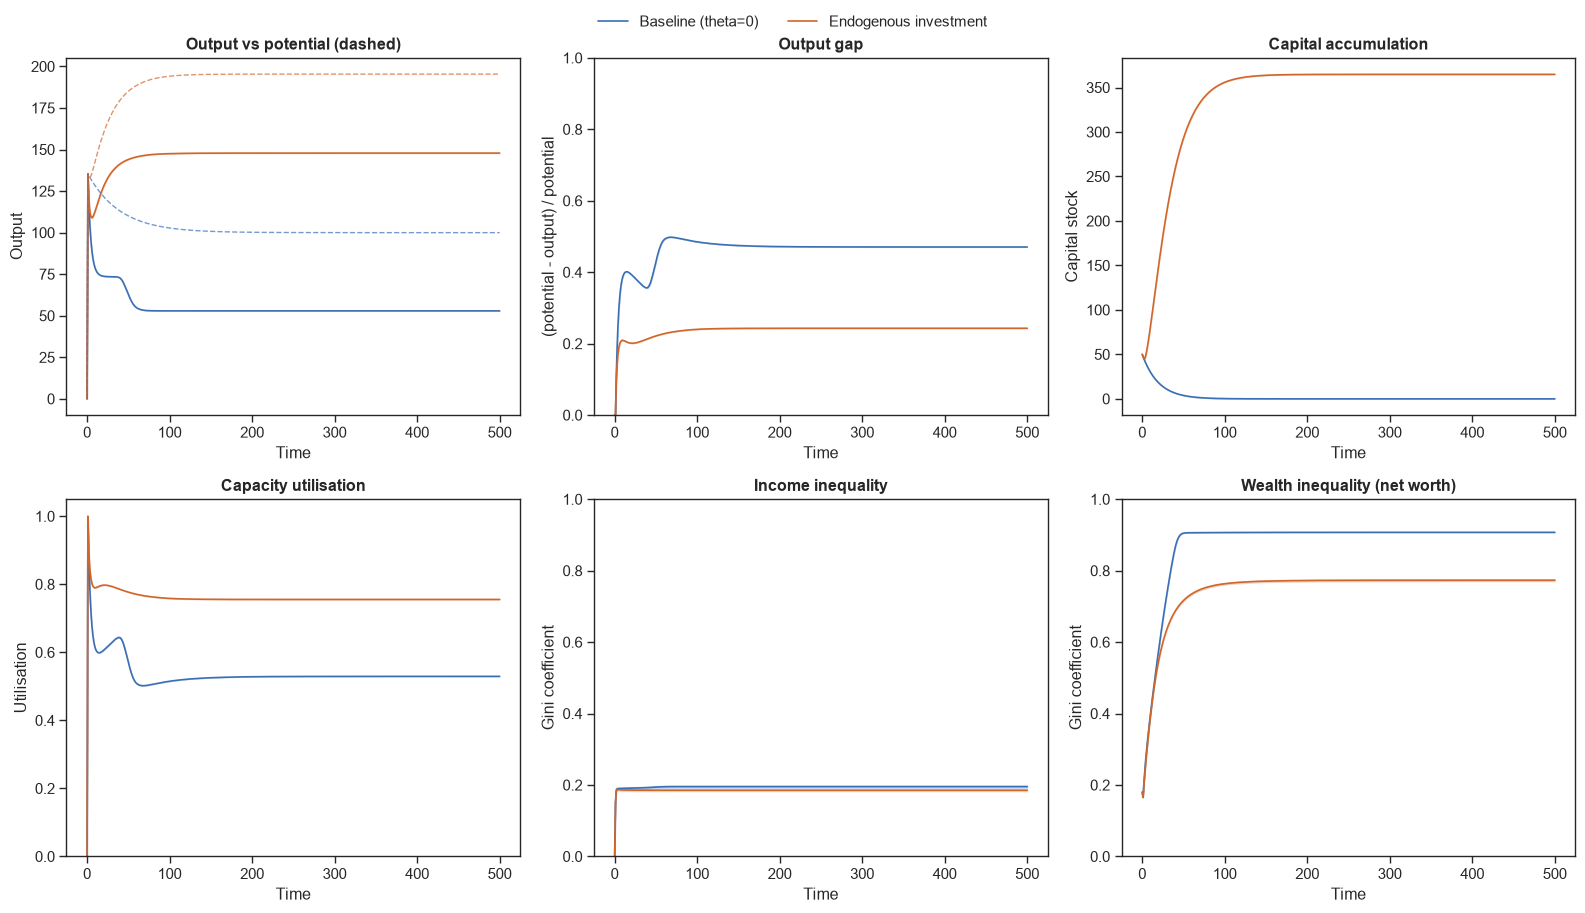

In [3]:
def band(ax, summ, col, label, color, potential=False):
    t = summ.index
    ax.plot(t, summ[f"{col}_mean"], label=label, color=color)
    ax.fill_between(t, summ[f"{col}_lo"], summ[f"{col}_hi"], color=color, alpha=0.20)

C_BASE, C_INV = "#3b6fb5", "#d1662a"

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# --- Output vs potential ---
ax = axes[0, 0]
band(ax, baseline,   "Output", "Baseline (theta=0)", C_BASE)
band(ax, investment, "Output", "Endogenous investment", C_INV)
ax.plot(baseline.index,   baseline["Potential_Output_mean"],   ls="--", lw=1, color=C_BASE, alpha=0.7)
ax.plot(investment.index, investment["Potential_Output_mean"], ls="--", lw=1, color=C_INV, alpha=0.7)
ax.set_title("Output vs potential (dashed)", weight="bold")
ax.set_xlabel("Time"); ax.set_ylabel("Output"); ax.legend()

# --- Output gap ---
ax = axes[0, 1]
band(ax, baseline,   "Output_Gap", "Baseline", C_BASE)
band(ax, investment, "Output_Gap", "Endogenous investment", C_INV)
ax.set_title("Output gap", weight="bold")
ax.set_xlabel("Time"); ax.set_ylabel("(potential - output) / potential"); ax.set_ylim(0, 1)

# --- Capital ---
ax = axes[0, 2]
band(ax, baseline,   "Total_Capital", "Baseline", C_BASE)
band(ax, investment, "Total_Capital", "Endogenous investment", C_INV)
ax.set_title("Capital accumulation", weight="bold")
ax.set_xlabel("Time"); ax.set_ylabel("Capital stock")

# --- Utilization ---
ax = axes[1, 0]
band(ax, baseline,   "Average_Utilization", "Baseline", C_BASE)
band(ax, investment, "Average_Utilization", "Endogenous investment", C_INV)
ax.set_title("Capacity utilisation", weight="bold")
ax.set_xlabel("Time"); ax.set_ylabel("Utilisation"); ax.set_ylim(0, 1.05)

# --- Income inequality ---
ax = axes[1, 1]
band(ax, baseline,   "Income_Gini", "Baseline", C_BASE)
band(ax, investment, "Income_Gini", "Endogenous investment", C_INV)
ax.set_title("Income inequality", weight="bold")
ax.set_xlabel("Time"); ax.set_ylabel("Gini coefficient"); ax.set_ylim(0, 1)

# --- Wealth inequality ---
ax = axes[1, 2]
band(ax, baseline,   "Wealth_Gini", "Baseline", C_BASE)
band(ax, investment, "Wealth_Gini", "Endogenous investment", C_INV)
ax.set_title("Wealth inequality (net worth)", weight="bold")
ax.set_xlabel("Time"); ax.set_ylabel("Gini coefficient"); ax.set_ylim(0, 1)

handles, labels = axes[0, 0].get_legend_handles_labels()
for ax in axes.flat:
    if ax.get_legend() is not None:
        ax.get_legend().remove()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout()
plt.savefig(os.path.join('..', 'macro_results.png'), dpi=200, bbox_inches="tight")
plt.show()


## 3. How much does the investment propensity matter?

Sweeping `theta` shows how the steady-state economy responds to the strength of
the savings-recycling channel — output and capital rise with `theta` at a
diminishing rate, and the output gap and wealth inequality fall.


In [4]:
thetas = [0.0, 0.025, 0.05, 0.075, 0.1, 0.15, 0.2, 0.3]
sweep = theta_sweep(thetas, steps=STEPS, seeds=20, tail=50)
sweep.round(3)


C:\Users\recursivechaos\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mesa\mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


,theta,Output,Potential_Output,Output_Gap,Total_Capital,Consumption,Investment,Total_Wealth,Income_Gini,Wealth_Gini,Average_Utilization
0,0.000,52.941,100.000,0.471,0.000,52.941,0.000,347.059,0.195,0.907,0.529
1,0.025,86.031,152.895,0.437,112.504,80.405,5.625,313.969,0.189,0.905,0.562
2,0.050,116.241,173.975,0.332,219.720,105.255,10.986,283.759,0.187,0.897,0.667
3,0.075,130.437,183.693,0.290,281.096,116.382,14.055,269.563,0.186,0.859,0.709
4,0.100,138.445,189.167,0.268,318.985,122.496,15.949,261.555,0.185,0.821,0.731
5,0.150,147.924,195.394,0.243,364.994,129.675,18.250,252.076,0.185,0.773,0.756
6,0.200,153.481,198.884,0.228,392.140,133.874,19.607,246.519,0.185,0.747,0.770
7,0.300,159.741,202.676,0.212,422.737,138.605,21.137,240.259,0.184,0.719,0.787


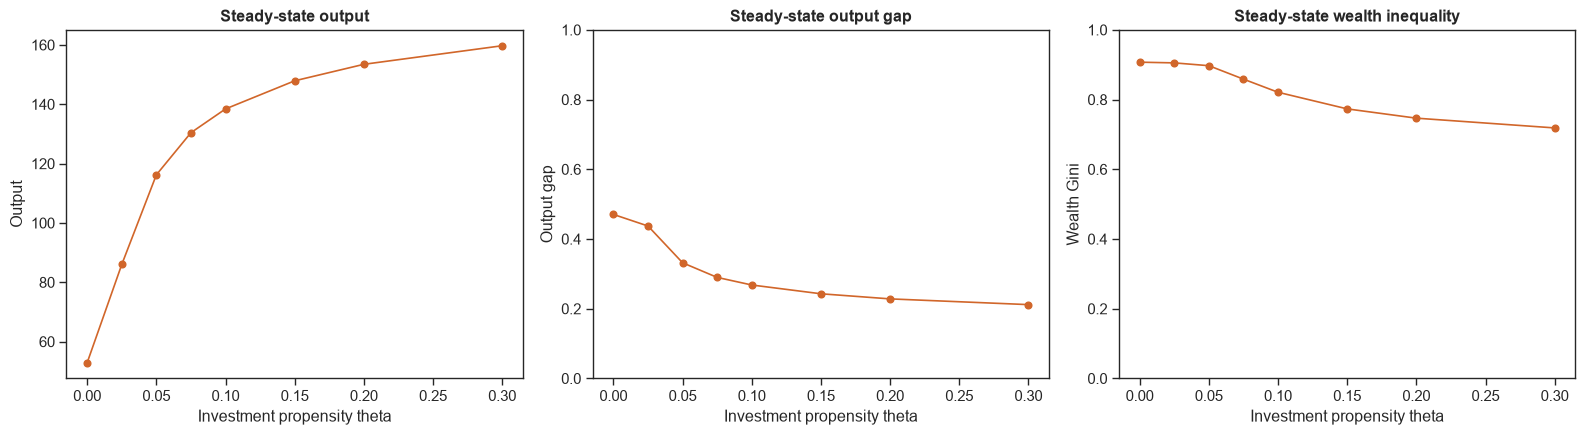

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(sweep["theta"], sweep["Output"], "o-", color=C_INV)
axes[0].set_title("Steady-state output", weight="bold")
axes[0].set_xlabel("Investment propensity theta"); axes[0].set_ylabel("Output")

axes[1].plot(sweep["theta"], sweep["Output_Gap"], "o-", color=C_INV)
axes[1].set_title("Steady-state output gap", weight="bold")
axes[1].set_xlabel("Investment propensity theta"); axes[1].set_ylabel("Output gap"); axes[1].set_ylim(0, 1)

axes[2].plot(sweep["theta"], sweep["Wealth_Gini"], "o-", color=C_INV)
axes[2].set_title("Steady-state wealth inequality", weight="bold")
axes[2].set_xlabel("Investment propensity theta"); axes[2].set_ylabel("Wealth Gini"); axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(os.path.join('..', 'theta_sweep.png'), dpi=200, bbox_inches="tight")
plt.show()


## 4. Answer to the research question

Reading the steady-state numbers off the sweep and the time-series comparison:

* **Yes — endogenous investment substantially mitigates demand-constrained
  stagnation.** Moving from `theta = 0` to a moderate `theta` roughly triples
  steady-state output and cuts the output gap by about half.
* **Two channels are at work.** Investment spending recycles the idle-savings
  leakage back into aggregate demand (the Keynesian multiplier channel), while
  the resulting capital raises productive capacity (the supply channel).
* **Inequality falls.** Converting hoarded money into productive capital and
  recycling it through wages lowers both income and wealth inequality relative
  to the hoarding baseline.
* **Diminishing returns.** Successive increases in `theta` add less and less
  output, because the economy moves from demand-constrained towards
  capacity-constrained territory (utilisation approaches its target).

The effect is *not* unconditional: it depends on capitalists holding an idle
savings stock to deploy and on that spending re-entering the income stream — the
mechanisms this stock-flow-consistent model makes explicit.
